# 04 Data Augmentation

Data augmentation means creating new training images from the images we already have. 

## Importing Libraries and Preparing the Data

We import the libraries, load the digits, enlarge them to 16 x 16 so that the augmentations have room to work, and split them into training (200 images), validation and test sets. We also create a small helper `show` that draws a row of images.

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from torch.utils.data import TensorDataset, DataLoader
digits = load_digits()
X = torch.tensor(digits.images / 16.0, dtype=torch.float32).unsqueeze(1)
X = F.interpolate(X, size=16, mode="bilinear", align_corners=False)
y = torch.tensor(digits.target)
X_train, X_rest, y_train, y_rest = train_test_split(X, y, train_size=200, random_state=0, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_rest, y_rest, test_size=0.5, random_state=0, stratify=y_rest)
print("Train / Validation / Test images:", len(X_train), len(X_val), len(X_test))
print("One image shape (C, H, W):", tuple(X_train[0].shape))
def show(images, titles):
    """Draw a row of small grayscale images"""
    fig, ax = plt.subplots(1, len(images), figsize=(2 * len(images), 2.2))
    for a, image, title in zip(ax, images, titles):
        a.imshow(image[0], cmap="gray", vmin=0, vmax=1)
        a.set_title(title, fontsize=9)
        a.axis("off")
    plt.show()

Train / Validation / Test images: 200 798 799
One image shape (C, H, W): (1, 16, 16)


**Code Explanation:** The digits have pixel values from 0 to 16, so we divide by 16 to get values between 0 and 1. `unsqueeze(1)` adds the channel dimension and `F.interpolate` enlarges every image from 8 x 8 to 16 x 16. We keep only 200 images for training on purpose, and the remaining images are split equally into validation and test sets. `stratify` keeps the same share of every digit in each part. The validation set is used to watch the training, and the test set is used only at the end. The `show` helper draws a row of images with their titles.

## 1. Why Augmentation Is Required

**Definition:** Data augmentation creates new training images by making small, realistic changes to the existing images (for example shifting, rotating or changing the brightness) while keeping the same label.

**Example:** A photo of a cat shifted a little to the left is still a cat. A digit 2 moved by two pixels is still a 2. One original image can give many slightly different training images.

**Why it is used?** There are three main reasons:
1. Collecting and labelling new images is slow and expensive, and a small dataset makes the model memorize the images (overfitting).
2. Real images are never perfectly the same: the object can be shifted, tilted, bigger, smaller, brighter or darker.
3. Augmentation teaches the model that such changes do not change the answer, so it works better on new images.

Number of training images: 200
Pixels that changed after a 2 pixel shift: 81.2 percent


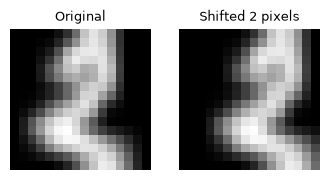

In [2]:
digit = X[2]
shifted = TF.affine(digit, angle=0, translate=[2, 0], scale=1.0, shear=[0.0, 0.0])
changed = (digit != shifted).float().mean().item() * 100
print("Number of training images:", len(X_train))
print("Pixels that changed after a 2 pixel shift: %.1f percent" % changed)
show([digit, shifted], ["Original", "Shifted 2 pixels"])

**Code Explanation:** `TF.affine` moves the digit 2 pixels to the right. To a person both pictures are clearly the same digit. But about 81 percent of the pixel numbers are different, so for a network that has seen only the left picture, the right picture is a new input. If the training set is small and always has centred digits, the model may never learn that a shifted digit is still the same digit. Augmentation shows the model such variations during training. The next sections show the common augmentations one at a time.

## 2. Horizontal Flip

**Definition:** A horizontal flip mirrors the image from left to right, like looking at it in a mirror. In training we use `RandomHorizontalFlip(p=0.5)`, which flips the image in half of the cases.

**Example:** A photo of a car facing left becomes a car facing right. Both are still cars.

**Why it is used?** It doubles the variety of the data for objects whose meaning does not depend on left or right, such as animals, cars, flowers and faces. It must not be used when left and right matter, such as digits and letters.

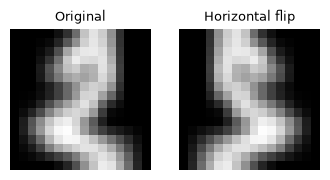

In [3]:
flip_h = T.RandomHorizontalFlip(p=1.0)
show([digit, flip_h(digit)], ["Original", "Horizontal flip"])

**Code Explanation:** `p=1.0` means the image is flipped every time, so we can see the effect. In real training we use `p=0.5`. The right picture is a mirrored 2. It is not a normal digit any more, so for handwritten digits this augmentation is a bad idea. We test this at the end of the notebook. For natural photos like animals or flowers, a horizontal flip is safe and very common.

## 3. Vertical Flip

**Definition:** A vertical flip turns the image upside down (top to bottom). We use `RandomVerticalFlip(p=0.5)` in training.

**Example:** A satellite photo or a microscope slide looks equally valid when it is turned upside down. A photo of a street does not, because the sky is never below the road.

**Why it is used?** It gives more variety for data that has no fixed up or down direction, such as aerial images and medical or microscope images. It is wrong for data where up and down have a meaning.

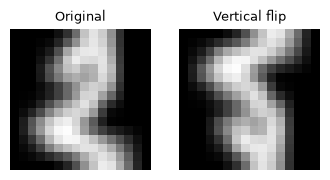

In [4]:
flip_v = T.RandomVerticalFlip(p=1.0)
show([digit, flip_v(digit)], ["Original", "Vertical flip"])

**Code Explanation:** The right picture is the digit 2 upside down. It no longer looks like a normal 2, so for digits a vertical flip is also not suitable. The code is almost the same as the horizontal flip, only the direction is different. Always ask whether the flipped image is still a realistic picture of the same class.

## 4. Rotation

**Definition:** Rotation turns the image by an angle around its centre. `RandomRotation(20)` rotates the image by a random angle between -20 and +20 degrees. The empty corners are filled with 0 (black) by default.

**Example:** People write digits a little tilted, and photos are taken with a slightly tilted camera.

**Why it is used?** It makes the model tolerant to small tilts. The angle should be small and realistic: turning a digit 6 by 180 degrees makes it look like a 9.

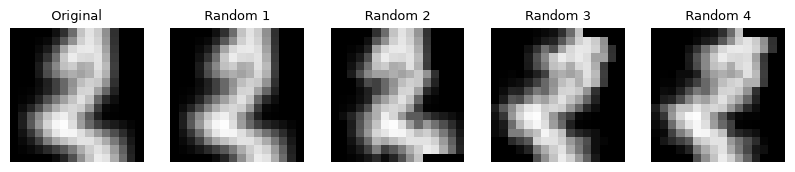

In [5]:
torch.manual_seed(0)
rotate = T.RandomRotation(20)
show([digit] + [rotate(digit) for _ in range(4)], ["Original", "Random 1", "Random 2", "Random 3", "Random 4"])

**Code Explanation:** We apply the same `RandomRotation(20)` four times to the same digit and get four different tilted versions, all still clearly a 2. `torch.manual_seed(0)` makes the random angles the same every time we run the cell. A small angle like 20 degrees keeps the meaning. A large angle could change the meaning, so the right limit depends on the dataset.

## 5. Random Crop

**Definition:** Random crop cuts out a part of the image from a random position. When we first add a border of zeros (padding), the crop moves the object inside the frame and the output keeps the same size. `RandomCrop(16, padding=3)` does this.

**Example:** The same digit appears a little higher, lower, left or right in each training picture.

**Why it is used?** The model learns to recognize an object wherever it sits in the picture and whether or not a small part of it is cut off at the border.

Output shape: (1, 16, 16)


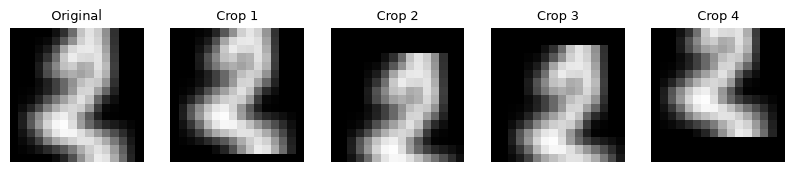

In [6]:
torch.manual_seed(0)
crop = T.RandomCrop(16, padding=3)
results = [crop(digit) for _ in range(4)]
print("Output shape:", tuple(results[0].shape))
show([digit] + results, ["Original", "Crop 1", "Crop 2", "Crop 3", "Crop 4"])

**Code Explanation:** The padding adds 3 pixels of zeros on every side, so the image becomes 22 x 22. Then a 16 x 16 window is cut out from a random position. The output shape stays (1, 16, 16), but the digit appears at a different place each time, and sometimes a small part of it is cut at the border. A crop that is too small could cut away the important part of the object, so the padding size must be chosen carefully.

## 6. Resize

**Definition:** Resize changes the size of the image. As an augmentation, we use `RandomResizedCrop`, which cuts a random part of the image (a random zoom) and resizes it back to a fixed size. We can also make the image smaller and then bigger, which makes it blurry like a low quality photo.

**Example:** The same object is photographed from near and from far. Near means it looks big and far means it looks small.

**Why it is used?** It makes the model tolerant to changes in object size and to images of different quality.

Small shape : (1, 8, 8)
Blurry shape: (1, 16, 16)


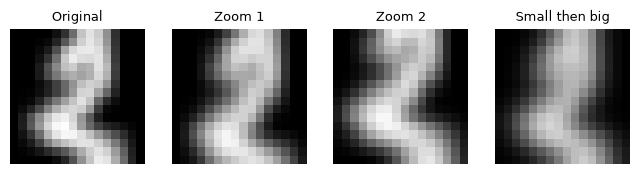

In [7]:
torch.manual_seed(0)
zoom = T.RandomResizedCrop(16, scale=(0.6, 1.0), antialias=True)
small = T.Resize(8, antialias=True)(digit)
blurry = T.Resize(16, antialias=True)(small)
print("Small shape :", tuple(small.shape))
print("Blurry shape:", tuple(blurry.shape))
show([digit, zoom(digit), zoom(digit), blurry], ["Original", "Zoom 1", "Zoom 2", "Small then big"])

**Code Explanation:** `RandomResizedCrop(16, scale=(0.6, 1.0))` keeps a random part of the image (between 60 and 100 percent of it) and resizes it back to 16 x 16, so the digit looks bigger and in a different position each time. In the last picture, `T.Resize(8)` shrinks the image to 8 x 8 and `T.Resize(16)` enlarges it again, so the picture becomes blurry because the details were lost. Both pictures have the same final size, (1, 16, 16), so the network accepts them.

## 7. Translation

**Definition:** Translation moves the whole image up, down, left or right by a few pixels. In `RandomAffine`, the option `translate=(0.2, 0.2)` allows a random move of up to 20 percent of the width and of the height.

**Example:** A digit written a little to the left or a little lower in the box.

**Why it is used?** A CNN is partly tolerant to position because of its shared kernels and pooling, but it is not fully tolerant. Translation augmentation makes this tolerance stronger.

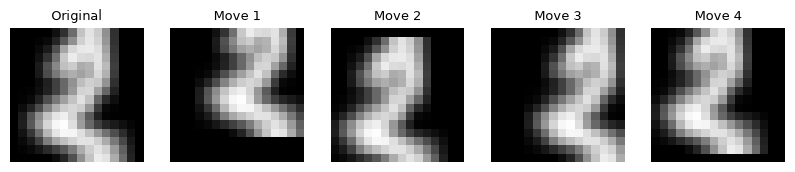

In [8]:
torch.manual_seed(0)
move = T.RandomAffine(degrees=0, translate=(0.2, 0.2))
show([digit] + [move(digit) for _ in range(4)], ["Original", "Move 1", "Move 2", "Move 3", "Move 4"])

**Code Explanation:** `degrees=0` switches off rotation, so only the translation is applied. With `translate=(0.2, 0.2)` and a 16 pixel image, the digit can move up to about 3 pixels horizontally and vertically. The empty space is filled with 0 (black), which is the same as the background of the digits. If the background had another colour, we would have to change the fill value.

## 8. Brightness and Contrast Changes

**Definition:** Brightness changes how light or dark the whole image is. Contrast changes the difference between the light and dark areas. `ColorJitter(brightness=0.5, contrast=0.5)` changes both by a random amount.

**Example:** The same photo taken in a bright room, in a dark room, or with a weak scanner.

**Why it is used?** It makes the model work under different lighting conditions. It is useful for photos, but it is not useful when the brightness itself carries the meaning (for example some medical scans).

Original  -> smallest: 0.0 largest: 0.99
Changed 1 -> smallest: 0.04088851436972618 largest: 0.55


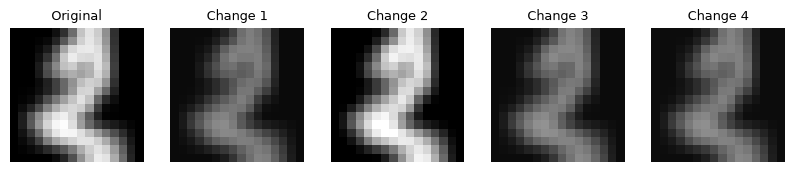

In [9]:
torch.manual_seed(0)
jitter = T.ColorJitter(brightness=0.5, contrast=0.5)
results = [jitter(digit) for _ in range(4)]
print("Original  -> smallest:", digit.min().item(), "largest: %.2f" % digit.max().item())
print("Changed 1 -> smallest:", results[0].min().item(), "largest: %.2f" % results[0].max().item())
show([digit] + results, ["Original", "Change 1", "Change 2", "Change 3", "Change 4"])

**Code Explanation:** Each version is a little brighter or darker, or has a different contrast. The printed values show the effect of the first change: the smallest pixel value rises from 0.0 to about 0.04 and the largest value drops from 0.99 to about 0.55. So that picture became darker and also lower in contrast: the white strokes are greyer and the black background is slightly lighter. The values are always kept between 0 and 1. Digits have a plain black background, so these changes are less important for them than for natural photos. For coloured photos, `ColorJitter` can also change saturation and hue.

## 9. Random Affine Transformation

**Definition:** An affine transformation combines several geometric changes in one step: rotation, translation, scaling (zoom) and shearing (slanting). `RandomAffine` picks a random value for each of them within the limits we give.

**Example:** `RandomAffine(degrees=15, translate=(0.125, 0.125), scale=(0.9, 1.1), shear=5)` tilts the image up to 15 degrees, moves it up to 12.5 percent, zooms it between 90 and 110 percent and slants it up to 5 degrees.

**Why it is used?** One transform gives many different combinations of small changes, so it is a simple and powerful default for images where position, tilt and size can vary. We use it in the experiment that follows.

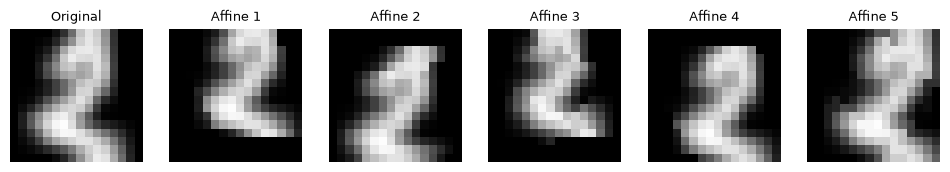

In [10]:
torch.manual_seed(0)
affine = T.RandomAffine(degrees=15, translate=(0.125, 0.125), scale=(0.9, 1.1), shear=5)
show([digit] + [affine(digit) for _ in range(5)], ["Original", "Affine 1", "Affine 2", "Affine 3", "Affine 4", "Affine 5"])

**Code Explanation:** We apply the same `affine` transform five times to the same digit. Every picture is different: slightly tilted, moved, bigger or smaller, or slanted, but it is still clearly the digit 2. The limits are small on purpose, so the label stays correct. This `affine` object is the augmentation used for the "with augmentation" model in the experiment.

## 10. Setting Up the Experiment

**Definition:** To compare two training methods fairly, we use the same data, the same model, the same settings and the same number of epochs. Only one thing is different: whether the training images are augmented or not.

**Example:** Model A is trained on the 200 original training images. Model B is trained on the same 200 images, but every time an image is used, it is randomly changed by the `affine` transform.

**Why it is used?** If more than one thing changes between the two models, we cannot know which change caused the difference in the result.

We also create an extra **shifted test set**. It has the same test digits, but each one is moved and rotated a little, like pictures from a new camera. It shows how well a model works when the new images are not exactly like the training images.

Test images        : (799, 1, 16, 16)
Shifted test images: (799, 1, 16, 16)
Learnable numbers in the CNN: 38282


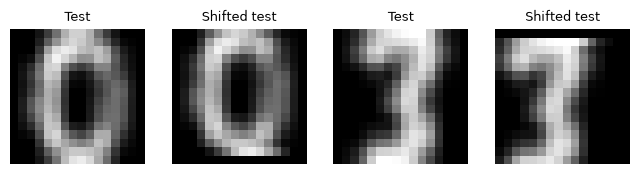

In [11]:
torch.manual_seed(123)
shift = T.RandomAffine(degrees=10, translate=(0.125, 0.125))
X_test_shifted = torch.stack([shift(image) for image in X_test])
def make_cnn():
    return nn.Sequential(
        nn.Conv2d(1, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        nn.Flatten(),
        nn.Linear(32 * 4 * 4, 64), nn.ReLU(),
        nn.Linear(64, 10)
    )
print("Test images        :", tuple(X_test.shape))
print("Shifted test images:", tuple(X_test_shifted.shape))
print("Learnable numbers in the CNN:", sum(p.numel() for p in make_cnn().parameters()))
show([X_test[0], X_test_shifted[0], X_test[1], X_test_shifted[1]], ["Test", "Shifted test", "Test", "Shifted test"])

**Code Explanation:** We apply a fixed random shift and rotation (up to 10 degrees and about 2 pixels) once to every test image, and save the result as `X_test_shifted`. The seed makes it the same every time. These shifted images are used only for testing and never for training. `make_cnn` builds a small CNN with two convolution blocks and two fully connected layers. Both models in the experiment start from this same architecture. The pictures show two test digits and their shifted copies.

## 11. Training Without and With Augmentation

**Definition:** Training means showing the training images to the network many times and changing its weights to reduce the error. One full pass over all the training images is one epoch. With augmentation, every image is randomly changed each time it is used, so the model rarely sees exactly the same picture twice.

**Example:** We train for 40 epochs with the Adam optimizer. After every epoch we measure the accuracy and the loss on the training images and on the validation images. Augmentation is used only while training, never while measuring.

**Why it is used?** The curves over the epochs show how the model learns and when it starts to overfit.

We train three setups, each with 3 different random seeds (the starting weights and the random changes are different in each run), so that the result does not depend on luck:
1. No augmentation
2. With augmentation (the `affine` transform)
3. Wrong augmentation (horizontal and vertical flips), which we examine at the end

In [13]:
def evaluate(model, images, labels):
    model.eval()
    with torch.no_grad():
        scores = model(images)
    accuracy = (scores.argmax(dim=1) == labels).float().mean().item()
    loss = F.cross_entropy(scores, labels).item()
    return accuracy, loss
def train_model(augment=None, epochs=40, seed=0):
    torch.manual_seed(seed)
    model = make_cnn()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.003)
    loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
    history = {"train_acc": [], "val_acc": [], "val_loss": []}
    start = time.time()
    for epoch in range(epochs):
        model.train()
        for images, labels in loader:
            if augment is not None:
                images = torch.stack([augment(image) for image in images])
            optimizer.zero_grad()
            loss = F.cross_entropy(model(images), labels)
            loss.backward()
            optimizer.step()
        history["train_acc"].append(evaluate(model, X_train, y_train)[0])
        val_acc, val_loss = evaluate(model, X_val, y_val)
        history["val_acc"].append(val_acc)
        history["val_loss"].append(val_loss)
    history["time"] = time.time() - start
    return model, history

**Code Explanation:** `evaluate` returns the accuracy and the loss of a model on some images. It switches the model to evaluation mode and does not apply any augmentation, so the measurement is always done on the original, unchanged images. `train_model` trains a new CNN. The only difference between the models is the line `if augment is not None`: when an augmentation is given, every image of every batch is randomly changed before it enters the model. After every epoch we save the training accuracy, the validation accuracy and the validation loss, and at the end we save the training time. The next cell runs it.

In [14]:
setups = {
    "No augmentation": None,
    "With augmentation": affine,
    "Wrong augmentation (flips)": T.Compose([T.RandomHorizontalFlip(), T.RandomVerticalFlip()]),
}
runs = {}
for name in setups:
    runs[name] = [train_model(setups[name], epochs=40, seed=seed) for seed in range(3)]
    print(name, "done")

No augmentation done
With augmentation done
Wrong augmentation (flips) done


**Code Explanation:** For each of the three setups we train 3 models with seeds 0, 1 and 2, so there are 9 models in total. Each entry in `runs` is a list of 3 pairs (model, history). From here on we only read the results. Every number in the next sections is the average of the 3 seeds, unless we say it comes from one run. The exact numbers can change a little on another computer, but the overall picture should stay the same.

## 12. Effect on Training Accuracy

**Definition:** Training accuracy is the share of the training images that the model classifies correctly. We measure it on the original training images at the end of training.

**Example:** If a model has 100 percent training accuracy, it classifies every one of its training images correctly. That can mean the model has learned the pattern, or it can mean that it has simply memorized the images.

**Why it is used?** Training accuracy tells how well the model fits the data it has seen. By itself it says nothing about new images, so we always read it together with the validation accuracy.

In [15]:
for name in runs:
    final = [history["train_acc"][-1] for model, history in runs[name]]
    print(name.ljust(28), "training accuracy: %.1f percent" % (np.mean(final) * 100))

No augmentation              training accuracy: 100.0 percent
With augmentation            training accuracy: 97.2 percent
Wrong augmentation (flips)   training accuracy: 88.8 percent


**Code Explanation:** For each setup we take the training accuracy after the last epoch from each of the 3 runs and print the average. Without augmentation the training accuracy is 100.0 percent: the model classifies every one of its 200 training images correctly. With augmentation it is lower (97.2 percent), and with the wrong flips it is the lowest (89.2 percent). A lower training accuracy with augmentation is expected and is not a problem: the training task is harder because the images keep changing, so the model cannot simply memorize them. What matters more is the validation accuracy, which comes next.

## 13. Effect on Validation Accuracy

**Definition:** Validation accuracy is the share of the validation images (images the model never trained on) that the model classifies correctly.

**Example:** A student who memorizes the answers of the practice questions gets full marks on them, but a lower mark in a new exam with different questions. The validation set is that new exam.

**Why it is used?** It shows how well the model works on new images. It is the number we trust more when we compare models.

No augmentation              validation accuracy: 92.1 percent
With augmentation            validation accuracy: 92.9 percent
Wrong augmentation (flips)   validation accuracy: 80.4 percent


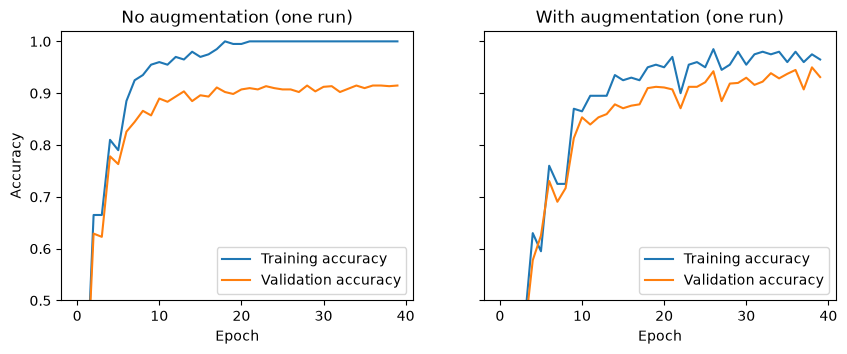

In [16]:
for name in runs:
    final = [history["val_acc"][-1] for model, history in runs[name]]
    print(name.ljust(28), "validation accuracy: %.1f percent" % (np.mean(final) * 100))
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)
for a, name in zip(ax, ["No augmentation", "With augmentation"]):
    history = runs[name][0][1]
    a.plot(history["train_acc"], label="Training accuracy")
    a.plot(history["val_acc"], label="Validation accuracy")
    a.set_title(name + " (one run)")
    a.set_xlabel("Epoch")
    a.set_ylim(0.5, 1.02)
    a.legend()
ax[0].set_ylabel("Accuracy")
plt.show()

**Code Explanation:** The printed numbers are the average final validation accuracy of the 3 runs. The two charts show the training accuracy and the validation accuracy after every epoch, for one run (seed 0) of each setup. Without augmentation the validation accuracy is 92.1 percent and with augmentation it is 92.9 percent, so augmentation is only 0.8 points better on average. This is a small difference: the augmented model was better in 2 of the 3 runs and slightly worse in 1 of them, so on this measure alone we cannot call it a clear win. In the charts, the model without augmentation reaches 100 percent training accuracy at about epoch 18 and then the line stays flat, while its validation accuracy stays at about 91 to 92 percent. With augmentation the training line is lower and moves up and down, the validation line is closer to it, but it is also noisy from one epoch to the next. So the validation accuracy alone hides most of the benefit. The next two sections show where the effect is clearer.

## 14. Effect on Overfitting

**Definition:** Overfitting happens when a model learns the training images too well, including their small details and noise, and then works worse on new images. The signs are a high training accuracy together with a clearly lower validation accuracy, and a validation loss that stops improving or starts to rise while the training accuracy still goes up.

**Example:** A model with 100 percent training accuracy but 92 percent validation accuracy has a gap of 8 points. A smaller gap means less overfitting.

**Why it is used?** The gap between training and validation accuracy is the simplest way to measure overfitting. Augmentation is one of the main tools to reduce it.

No augmentation              gap: 7.9 points | validation loss: lowest 0.27, final 0.33
With augmentation            gap: 4.3 points | validation loss: lowest 0.18, final 0.20
Wrong augmentation (flips)   gap: 8.5 points | validation loss: lowest 0.63, final 0.63


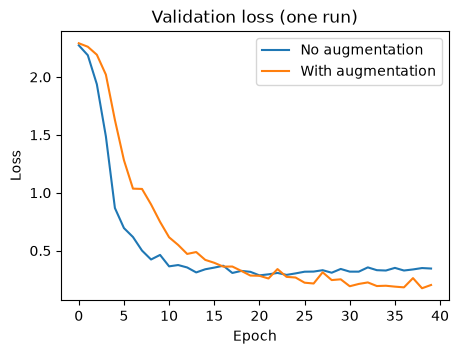

In [17]:
for name in runs:
    train_acc = np.mean([history["train_acc"][-1] for model, history in runs[name]]) * 100
    val_acc = np.mean([history["val_acc"][-1] for model, history in runs[name]]) * 100
    best_loss = np.mean([min(history["val_loss"]) for model, history in runs[name]])
    last_loss = np.mean([history["val_loss"][-1] for model, history in runs[name]])
    print(name.ljust(28), "gap: %.1f points" % (train_acc - val_acc),
          "| validation loss: lowest %.2f, final %.2f" % (best_loss, last_loss))
plt.figure(figsize=(5, 3.5))
for name in ["No augmentation", "With augmentation"]:
    plt.plot(runs[name][0][1]["val_loss"], label=name)
plt.title("Validation loss (one run)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

**Code Explanation:** The gap is the training accuracy minus the validation accuracy, in percentage points. We also print the lowest validation loss reached during training and the final validation loss: when the final loss is clearly higher than the lowest loss, the model got worse on new images while it kept improving on the training images. The chart shows the validation loss over the epochs for one run of each setup. Without augmentation the gap is 7.9 points. With augmentation it is 4.3 points, which is about 45 percent smaller. Without augmentation the validation loss is lowest at about epoch 15 to 21 (0.27 on average) and then rises to 0.33 at the end, while the training accuracy is already 100 percent: the model keeps fitting the training images and gets worse on new ones, which is overfitting. With augmentation the lowest validation loss is lower (0.18), the final loss is almost the same as the lowest (0.20), and the lowest point comes late (epoch 35 to 39), so the model was still improving at the end. In the chart the line without augmentation turns upward after its lowest point, while the line with augmentation stays low (it starts higher because the augmented model learns more slowly at first). For the flipped setup the gap is 8.5 points, but its lowest validation loss is much higher (0.63). That model is poor because it learns from misleading examples, not because it memorized the images, so the gap alone is not enough: always read the loss and the accuracy together.

## 15. Effect on Generalization

**Definition:** Generalization is how well a model works on images it has never seen. We measure it on the test set, which was not used for training and was not used to watch the training. We use two test sets: the normal test set, and the shifted test set that contains moved and tilted digits.

**Example:** A model that works well on neat, centred digits but fails on digits that are a little shifted has not generalized well.

**Why it is used?** Generalization is the real goal. A model is useful only if it works on new data.

                     Setup  Normal test accuracy (%)  Shifted test accuracy (%)
           No augmentation                      92.3                       62.1
         With augmentation                      93.2                       86.8
Wrong augmentation (flips)                      79.0                       45.4


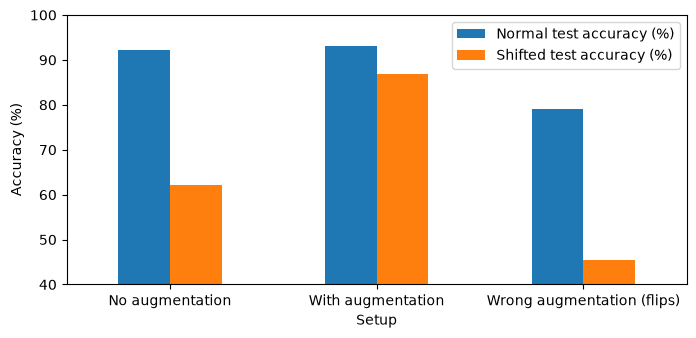

In [18]:
rows = []
for name in runs:
    clean = np.mean([evaluate(model, X_test, y_test)[0] for model, history in runs[name]])
    moved = np.mean([evaluate(model, X_test_shifted, y_test)[0] for model, history in runs[name]])
    rows.append({"Setup": name,
                 "Normal test accuracy (%)": round(clean * 100, 1),
                 "Shifted test accuracy (%)": round(moved * 100, 1)})
generalization = pd.DataFrame(rows)
print(generalization.to_string(index=False))
generalization.set_index("Setup").plot(kind="bar", figsize=(8, 3.5), rot=0, ylim=(40, 100))
plt.ylabel("Accuracy (%)")
plt.show()

**Code Explanation:** For every setup we test the 3 trained models on the normal test set and on the shifted test set and print the average accuracy. The bar chart puts the two test results side by side (the vertical axis starts at 40 so that the differences are visible). On the normal test set the two models are almost equal: 92.3 percent without augmentation and 93.0 percent with augmentation. On the shifted test set the difference is large: 62.0 percent without augmentation and 86.8 percent with augmentation, which is 24.8 points higher. The model trained without augmentation learned the digits only in the position and angle that it saw, and it fails when they move a little. The model trained with augmentation learned that a moved or tilted digit is still the same digit. One honest note: the shifted test set uses the kind of changes (small moves and tilts) that our augmentation was designed to cover, so the gain is large. For changes that the augmentation does not cover, the gain would be smaller. The flipped setup is worse than no augmentation on both test sets (78.9 and 45.5 percent).

## 16. When Augmentation Is Wrong

**Definition:** An augmentation is wrong for a dataset when it changes the meaning of the image, so the label is no longer correct. The model then learns from images that are mislabelled in effect.

**Example:** A mirrored digit 2 looks like a 5, and a digit 6 turned upside down and mirrored looks like a 9. If we flip digits during training, the model is told that these different shapes belong to the same digit.

**Why it is used?** It is the same lesson as in the preprocessing notebook: do not apply a technique just because it is popular. Look at your data and keep only the changes that keep the label true.

In [19]:
rows = []
for name in runs:
    results = runs[name]
    rows.append({
        "Setup": name,
        "Training acc (%)": round(np.mean([h["train_acc"][-1] for m, h in results]) * 100, 1),
        "Validation acc (%)": round(np.mean([h["val_acc"][-1] for m, h in results]) * 100, 1),
        "Normal test (%)": round(np.mean([evaluate(m, X_test, y_test)[0] for m, h in results]) * 100, 1),
        "Shifted test (%)": round(np.mean([evaluate(m, X_test_shifted, y_test)[0] for m, h in results]) * 100, 1),
        "Training time (s)": round(np.mean([h["time"] for m, h in results]), 1),
    })
pd.DataFrame(rows)

,Setup,Training acc (%),Validation acc (%),Normal test (%),Shifted test (%),Training time (s)
0,No augmentation,100.0,92.1,92.3,62.1,3.6
1,With augmentation,97.2,92.9,93.2,86.8,6.6
2,Wrong augmentation (flips),88.8,80.4,79.0,45.4,3.2


**Code Explanation:** The table collects all the results. The flipped setup is the worst on every accuracy measure: its validation accuracy is 80.7 percent against 92.1 percent without augmentation, and its shifted test accuracy is 45.5 percent. Its training accuracy is also low (89.2 percent) because the model is asked to give the same answer for shapes that look like different digits, which it cannot do. The small affine changes (the "With augmentation" row) keep the label true and give the best shifted test result. The last column shows the cost: on this computer, training with augmentation took 3.2 seconds on average against 1.9 seconds without it (about 1.7 times longer), because every image is changed one by one in every epoch. This dataset is tiny, so the times are small, but on a large dataset the extra cost is real.